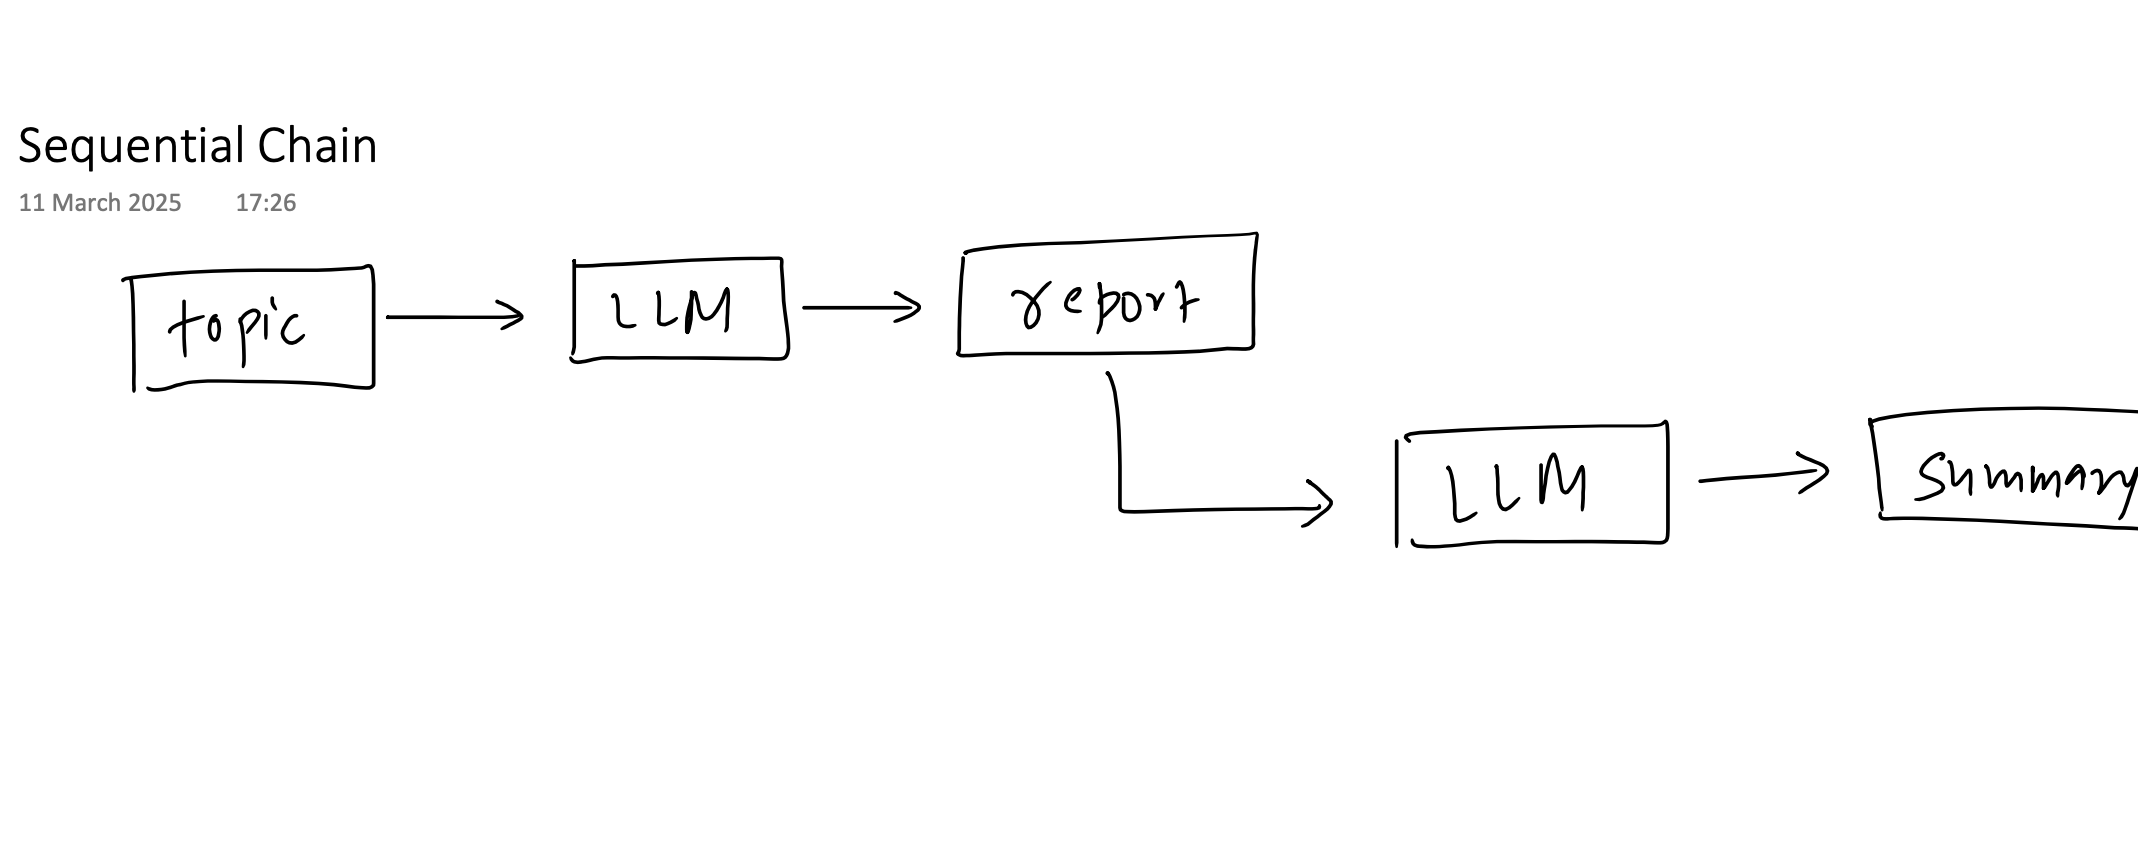

In this example, we create a chain that first generates a detailed report on a topic
and then summarizes that report into key points. This demonstrates chaining two
different LLM calls sequentially.
• Explanation:
1. We define two separate prompts.
▪ prompt1 : Asks for a detailed report on a
topic .
▪ prompt2 : Asks to generate a five-point
summary from a given text .
2. The chain is built by connecting the first prompt, model, and
parser. The output of the first parser (the detailed report)
becomes the input ( text ) for the second prompt, which is
then passed through another model and parser.
3. The flow is: User Input (topic) -> Prompt1 -> Model
-> Parser1 -> (Output becomes text for) ->
Prompt2 -> Model -> Parser2 -> Final Summary .

### 1.Intialize the model and parser

In [1]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

# Load environment variables
load_dotenv()

api_key = os.getenv("Hugging_face_api_token")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    # repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    huggingfacehub_api_token=api_key,
)

# Wrap with chat interface
model = ChatHuggingFace(llm=llm)

In [2]:
from langchain_core.output_parsers import StrOutputParser
parser=StrOutputParser()

### 2.Define Templates

In [3]:
from langchain_core.prompts import PromptTemplate
prompt1=PromptTemplate(
    template="Generate a detailed report on {topic}",
    input_variables=["topic"]
)
prompt2=PromptTemplate(
    template="Generate a 5 point summary on following text :\n {text}",
    input_variables=["text"]
)

### 3.define chain and invoke

In [4]:
chain = prompt1 | model | parser | prompt2 | model | parser

result=chain.invoke({
    "topic":"Unemployment in Nepal"
})

### 4.Output

In [5]:
print(f"Summarized Output: \n{result}")

Summarized Output: 
 1. Unemployment in Nepal remains high at 17.4% overall and 36.5% among youth in 2019.
2. Causes include a skills mismatch, brain drain, informal sector employment, political instability, and inadequate infrastructure.
3. Potential solutions are skills development through vocational education and training, entrepreneurship promotion, infrastructure development, diaspora engagement, and policy stability.
4. Nepal's rich cultural heritage and natural beauty offer opportunities for tourism and hydroelectric power development, but unemployment remains a significant challenge that needs to be addressed.


### 5.Graph Visualization

In [6]:
chain.get_graph().print_ascii()

     +-------------+       
     | PromptInput |       
     +-------------+       
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *              
   +-----------------+     
   | ChatHuggingFace |     
   +-----------------+     
            *              
            *              
            *              
   +-----------------+     
   | StrOutputParser |     
   +-----------------+     
            *              
            *              
            *              
+-----------------------+  
| StrOutputParserOutput |  
+-----------------------+  
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *       